# Renewable Asset Valuation & Hedging Strategy — France 2023

Hourly P&L of a 10 MW wind / solar portfolio rebuilt from RTE generation data and EPEX SPOT Day-Ahead prices, then a sweep of the PPA / spot hedge ratio to find the best risk-adjusted return.

**Sections:** 1. Data loading & cleaning · 2. Price data & merge · 3. Load seasonality · 4. Generation mix · 5. Load vs price · 6. Peak-load stress test · 7. Capture prices · 8. Portfolio revenues · 9. Hedge-ratio optimisation · 10. Strike sensitivity and natural hedge · 11. Reading the results

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# 1. DATA LOADING AND CLEANING (RTE eco2mix, 15-min)
# =============================================================================
RTE_FILE = 'donnees_rte_2023.csv'

def load_rte(path):
    """Load the RTE file, handling separator and encoding ambiguity."""
    try:
        df = pd.read_csv(path, sep=',', encoding='utf-8-sig', low_memory=False)
        if len(df.columns) < 5:            # wrong separator: everything in one column
            df = pd.read_csv(path, sep=';', encoding='utf-8-sig', low_memory=False)
    except UnicodeDecodeError:              # older exports
        df = pd.read_csv(path, sep=';', encoding='latin-1', low_memory=False)
    df.columns = df.columns.str.strip()
    return df.rename(columns={'Périmètre': 'Perimetre'})

df_raw = load_rte(RTE_FILE)
df_raw = df_raw[df_raw['Perimetre'] == 'France'].copy()

df_raw['Datetime'] = pd.to_datetime(df_raw['Date'] + ' ' + df_raw['Heures'], format='%m/%d/%y %H:%M', errors='coerce')
df_raw = df_raw.dropna(subset=['Datetime']).set_index('Datetime').sort_index()

# The :15 and :45 rows are empty (RTE publishes these series every 30 min).
# Only missing values are interpolated. Zeros are genuine and kept:
# solar at night, and a few hours with all coal units offline.
COLS = ['Consommation', 'Nucleaire', 'Hydraulique', 'Eolien', 'Solaire',
        'Gaz', 'Charbon', 'Fioul', 'Bioenergies']
for col in COLS:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')
    df_raw[col] = df_raw[col].interpolate(method='linear', limit_direction='both')

print(f"Loaded {df_raw.shape[0]} rows, from {df_raw.index.min()} to {df_raw.index.max()}")
print(f"Remaining missing values: {int(df_raw[COLS].isna().sum().sum())}")

Loaded 35040 rows, from 2023-01-01 00:00:00 to 2023-12-31 23:45:00
Remaining missing values: 0


In [2]:
# =============================================================================
# 2. PRICE DATA AND MERGE (EPEX SPOT Day-Ahead, hourly)
# =============================================================================
PRICE_FILE = 'epex_spot_dayahead_2023.csv'
df_prices = pd.read_csv(PRICE_FILE)

# The delivery period is 'start - end'. DST rows carry a '(CET)' / '(CEST)' suffix,
# which is removed before parsing so those hours are not silently lost.
start = (df_prices['MTU (CET/CEST)'].str.split(' - ').str[0]
         .str.replace(r'\s*\((CET|CEST)\)', '', regex=True))
df_prices['Datetime'] = pd.to_datetime(start, dayfirst=True, errors='coerce')
df_prices = (df_prices.dropna(subset=['Datetime'])
             .set_index('Datetime').sort_index()
             [['Day-ahead Price (EUR/MWh)']]
             .rename(columns={'Day-ahead Price (EUR/MWh)': 'Spot_Price'}))
df_prices['Spot_Price'] = pd.to_numeric(df_prices['Spot_Price'], errors='coerce')

# The repeated autumn hour (29 Oct, 02:00) appears twice on a naive local index: keep the first.
df_prices = df_prices[~df_prices.index.duplicated(keep='first')]

# Production resampled from 15 min to 1 h (mean power over the hour = MWh produced)
df_hourly = df_raw[['Solaire', 'Eolien', 'Consommation']].resample('h').mean()
df_market_clean = df_hourly.join(df_prices, how='inner')

print(f"Market dataset: {len(df_market_clean)} hours (the non-existent spring DST hour is dropped).")
print(df_market_clean.head(3))

Market dataset: 8759 hours (the non-existent spring DST hour is dropped).
                     Solaire     Eolien  Consommation  Spot_Price
Datetime                                                         
2023-01-01 00:00:00      0.0  14373.875     46608.875        0.00
2023-01-01 01:00:00      0.0  11026.500     45090.000       -0.10
2023-01-01 02:00:00      0.0  10287.000     44632.125       -1.33


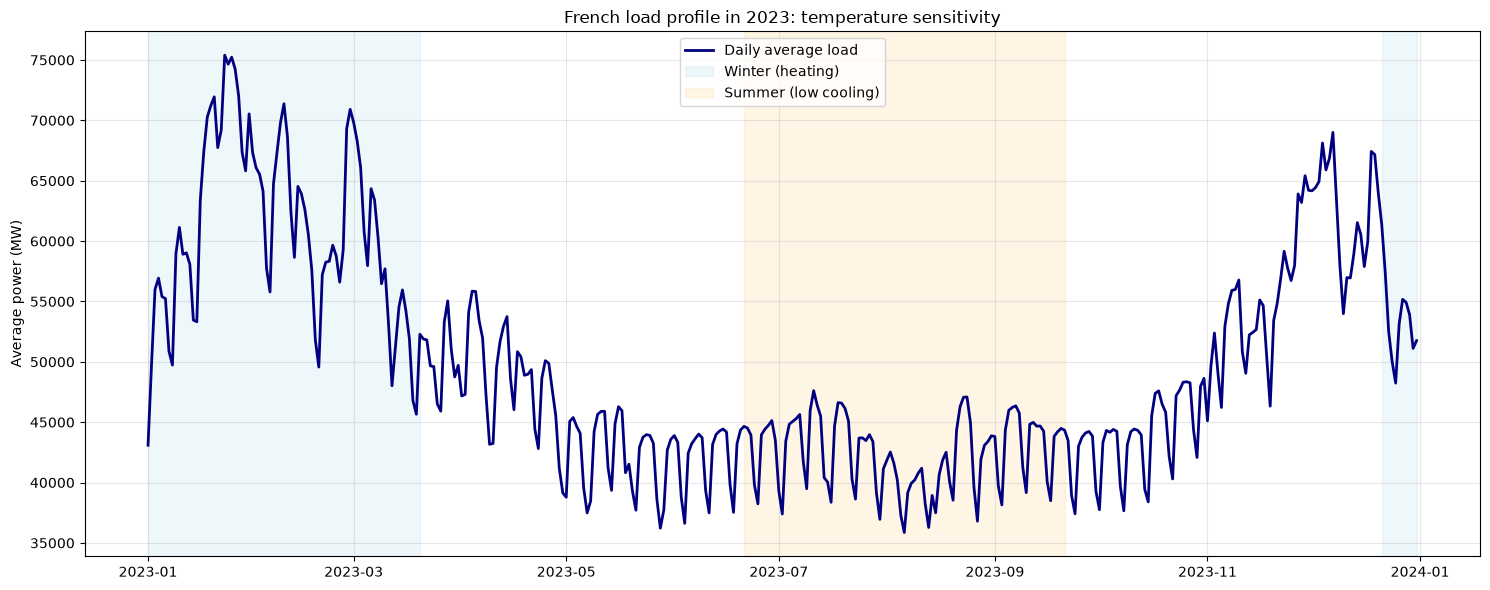

January average load : 62,701 MW
July average load    : 42,907 MW
Winter uplift        : +46.1%


In [3]:
# =============================================================================
# 3. LOAD SEASONALITY (temperature sensitivity)
# =============================================================================
df_daily = df_raw['Consommation'].resample('D').mean()

plt.figure(figsize=(15, 6))
plt.plot(df_daily.index, df_daily, color='navy', linewidth=2, label='Daily average load')
plt.axvspan('2023-01-01', '2023-03-20', color='lightblue', alpha=0.2, label='Winter (heating)')
plt.axvspan('2023-06-21', '2023-09-21', color='orange', alpha=0.1, label='Summer (low cooling)')
plt.axvspan('2023-12-21', '2023-12-31', color='lightblue', alpha=0.2)
plt.title("French load profile in 2023: temperature sensitivity")
plt.ylabel("Average power (MW)")
plt.legend(loc='upper center')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

jan = df_raw.loc['2023-01', 'Consommation'].mean()
jul = df_raw.loc['2023-07', 'Consommation'].mean()
print(f"January average load : {jan:,.0f} MW")
print(f"July average load    : {jul:,.0f} MW")
print(f"Winter uplift        : +{(jan - jul) / jul:.1%}")

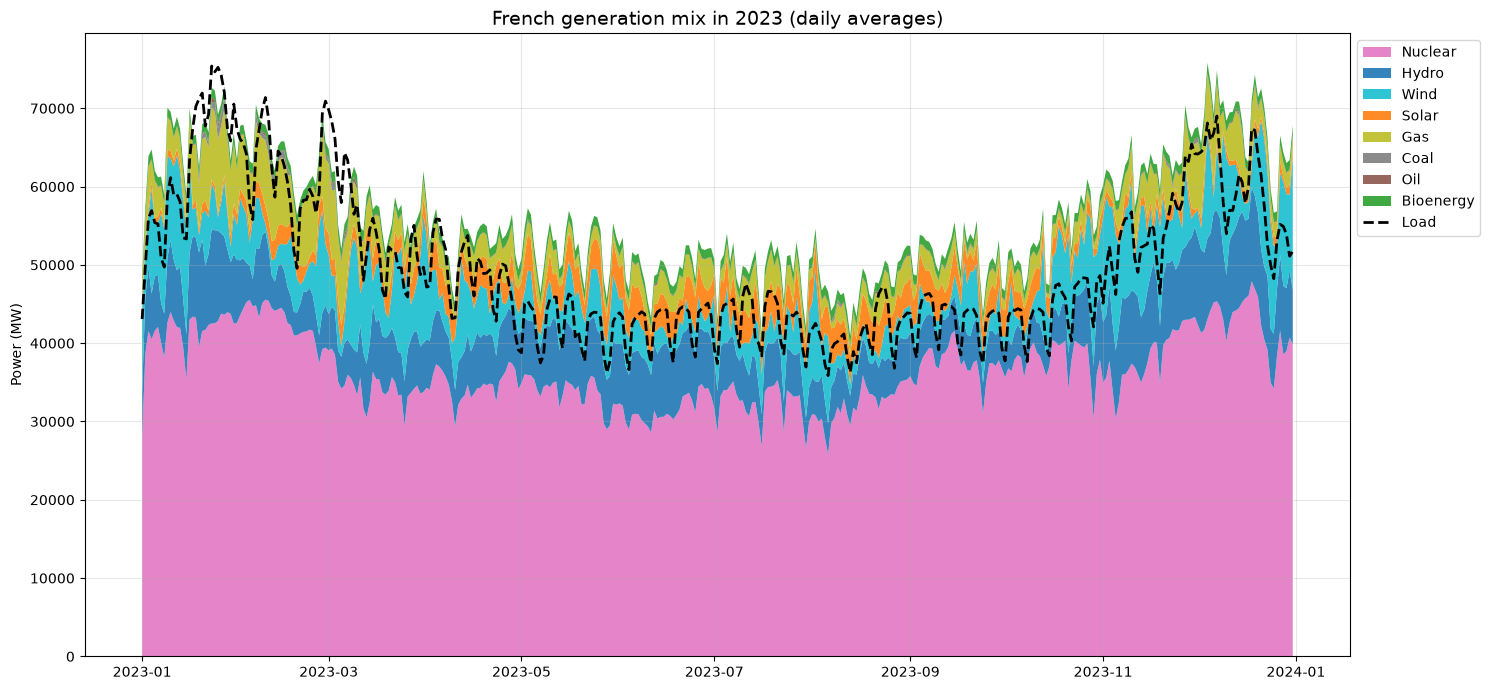

Average total generation: 56,230 MW


In [4]:
# =============================================================================
# 4. GENERATION MIX
# =============================================================================
PROD_COLS = ['Nucleaire', 'Hydraulique', 'Eolien', 'Solaire', 'Gaz', 'Charbon', 'Fioul', 'Bioenergies']
LABELS = {'Nucleaire': 'Nuclear', 'Hydraulique': 'Hydro', 'Eolien': 'Wind', 'Solaire': 'Solar',
          'Gaz': 'Gas', 'Charbon': 'Coal', 'Fioul': 'Oil', 'Bioenergies': 'Bioenergy'}
COLORS = {'Nucleaire': '#E377C2', 'Hydraulique': '#1F77B4', 'Bioenergies': '#2CA02C', 'Gaz': '#BCBD22',
          'Charbon': '#7F7F7F', 'Fioul': '#8C564B', 'Eolien': '#17BECF', 'Solaire': '#FF7F0E'}

df_mix = df_raw[PROD_COLS].resample('D').mean()

plt.figure(figsize=(15, 7))
plt.stackplot(df_mix.index, df_mix[PROD_COLS].T, labels=[LABELS[c] for c in PROD_COLS],
              colors=[COLORS[c] for c in PROD_COLS], alpha=0.9)
plt.plot(df_daily.index, df_daily, color='black', linewidth=2, linestyle='--', label='Load')
plt.title("French generation mix in 2023 (daily averages)", fontsize=14)
plt.ylabel("Power (MW)")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Average total generation: {df_mix.sum(axis=1).mean():,.0f} MW")

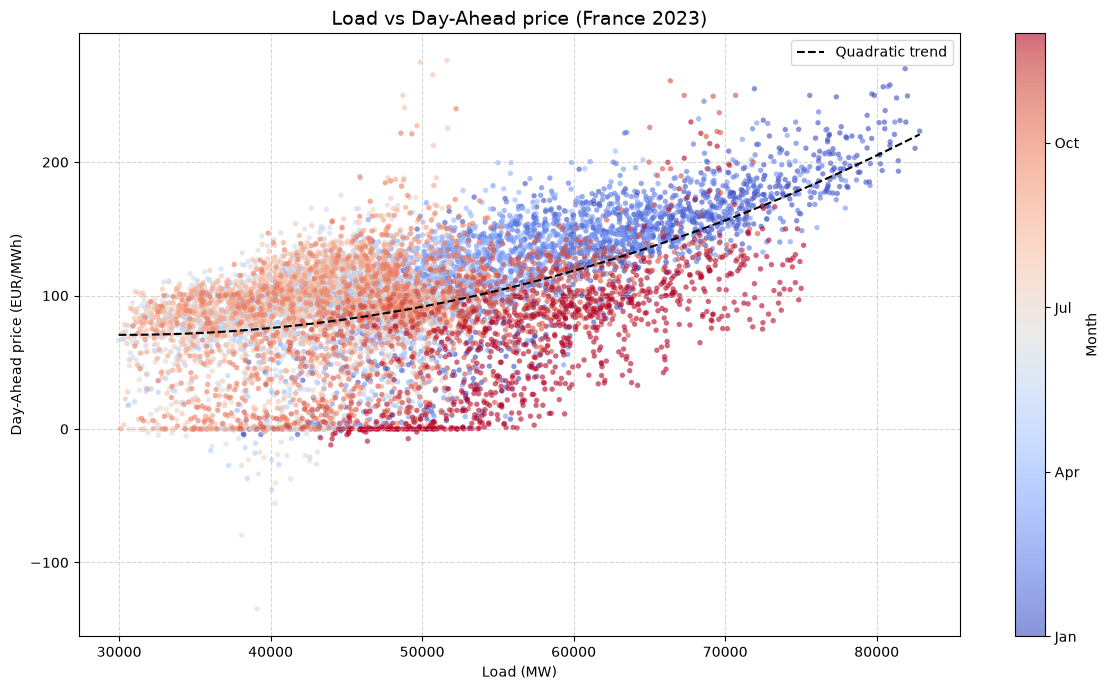

Correlation price / total load    : 0.55
Correlation price / residual load : 0.73
-> Price tracks residual load (load minus wind and solar) more closely than total load.

Negative-price hours: 147
  average load : 41,500 MW
  average wind : 5,558 MW
  average solar: 4,769 MW


In [5]:
# =============================================================================
# 5. LOAD VS PRICE: TOTAL LOAD AND RESIDUAL LOAD
# =============================================================================
m = df_market_clean
m['Residual_Load'] = m['Consommation'] - m['Eolien'] - m['Solaire']

plt.figure(figsize=(12, 7))
sc = plt.scatter(m['Consommation'], m['Spot_Price'], c=m.index.month, cmap='coolwarm',
                 alpha=0.6, edgecolors='none', s=15)
z = np.polyfit(m['Consommation'], m['Spot_Price'], 2)
x_trend = np.linspace(m['Consommation'].min(), m['Consommation'].max(), 100)
plt.plot(x_trend, np.poly1d(z)(x_trend), 'k--', linewidth=1.5, label='Quadratic trend')
plt.title("Load vs Day-Ahead price (France 2023)", fontsize=14)
plt.xlabel("Load (MW)")
plt.ylabel("Day-Ahead price (EUR/MWh)")
cbar = plt.colorbar(sc)
cbar.set_label('Month')
cbar.set_ticks([1, 4, 7, 10])
cbar.set_ticklabels(['Jan', 'Apr', 'Jul', 'Oct'])
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

corr_load = m['Consommation'].corr(m['Spot_Price'])
corr_resid = m['Residual_Load'].corr(m['Spot_Price'])
print(f"Correlation price / total load    : {corr_load:.2f}")
print(f"Correlation price / residual load : {corr_resid:.2f}")
print("-> Price tracks residual load (load minus wind and solar) more closely than total load.")

neg = m[m['Spot_Price'] < 0]
print(f"\nNegative-price hours: {len(neg)}")
if len(neg) > 0:
    print(f"  average load : {neg['Consommation'].mean():,.0f} MW")
    print(f"  average wind : {neg['Eolien'].mean():,.0f} MW")
    print(f"  average solar: {neg['Solaire'].mean():,.0f} MW")

Annual peak       : 83,757 MW on 23/01/2023 19:00
Wind + solar      : 8,231 MW (9.8% of load)
Residual load     : 75,526 MW
Day-Ahead price   : 223.19 EUR/MWh


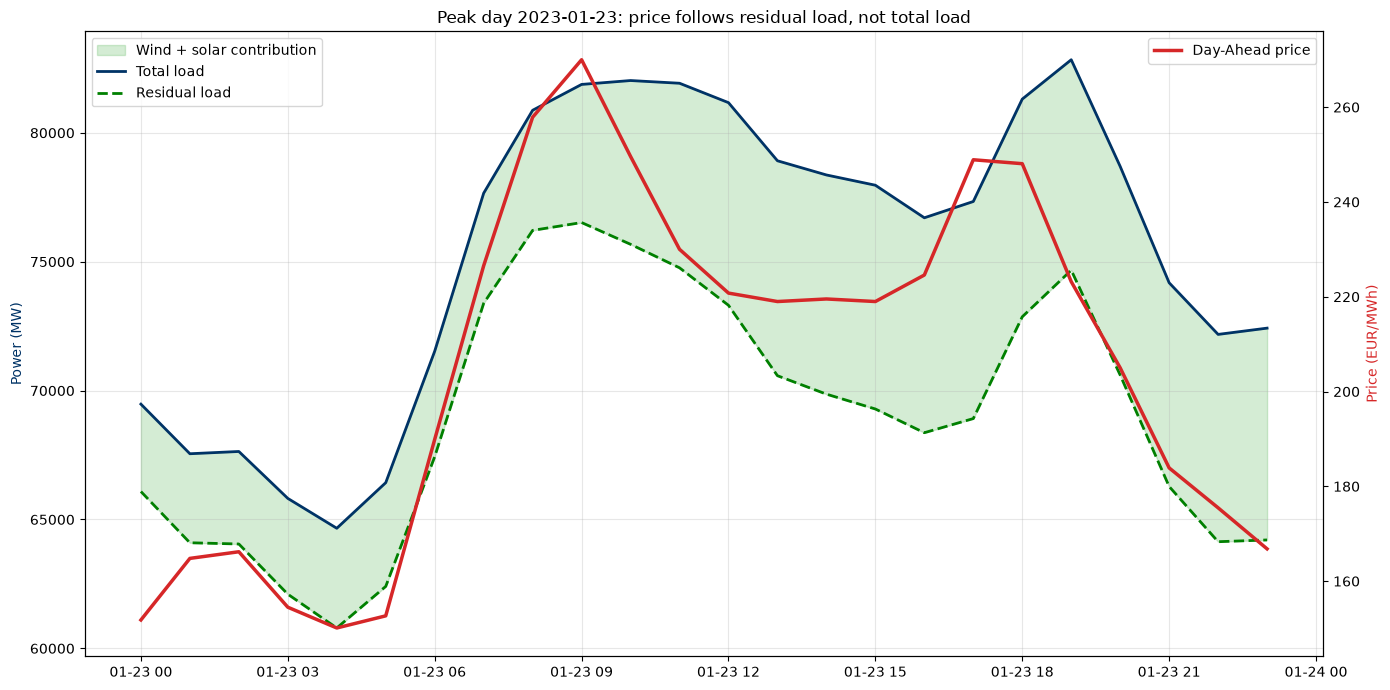

In [6]:
# =============================================================================
# 6. PEAK-LOAD STRESS TEST
# =============================================================================
idx_peak = df_raw['Consommation'].idxmax()
load_peak = df_raw.loc[idx_peak, 'Consommation']
price_peak = df_prices['Spot_Price'].asof(idx_peak)      # price of the delivery hour containing the peak

res_peak = df_raw.loc[idx_peak, 'Eolien'] + df_raw.loc[idx_peak, 'Solaire']
share_res = res_peak / load_peak
residual_peak = load_peak - res_peak

print(f"Annual peak       : {load_peak:,.0f} MW on {idx_peak:%d/%m/%Y %H:%M}")
print(f"Wind + solar      : {res_peak:,.0f} MW ({share_res:.1%} of load)")
print(f"Residual load     : {residual_peak:,.0f} MW")
print(f"Day-Ahead price   : {price_peak:.2f} EUR/MWh")

# Zoom on the peak day
day = idx_peak.strftime('%Y-%m-%d')
z = m.loc[day].copy()

fig, ax1 = plt.subplots(figsize=(14, 7))
ax1.fill_between(z.index, z['Residual_Load'], z['Consommation'], color='#2ca02c', alpha=0.2,
                 label='Wind + solar contribution')
ax1.plot(z.index, z['Consommation'], color='#003366', linewidth=2, label='Total load')
ax1.plot(z.index, z['Residual_Load'], color='green', linestyle='--', linewidth=2, label='Residual load')
ax1.set_ylabel('Power (MW)', color='#003366')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)
ax2 = ax1.twinx()
ax2.plot(z.index, z['Spot_Price'], color='#d62728', linewidth=2.5, label='Day-Ahead price')
ax2.set_ylabel('Price (EUR/MWh)', color='#d62728')
ax2.legend(loc='upper right')
plt.title(f"Peak day {day}: price follows residual load, not total load")
plt.tight_layout()
plt.show()

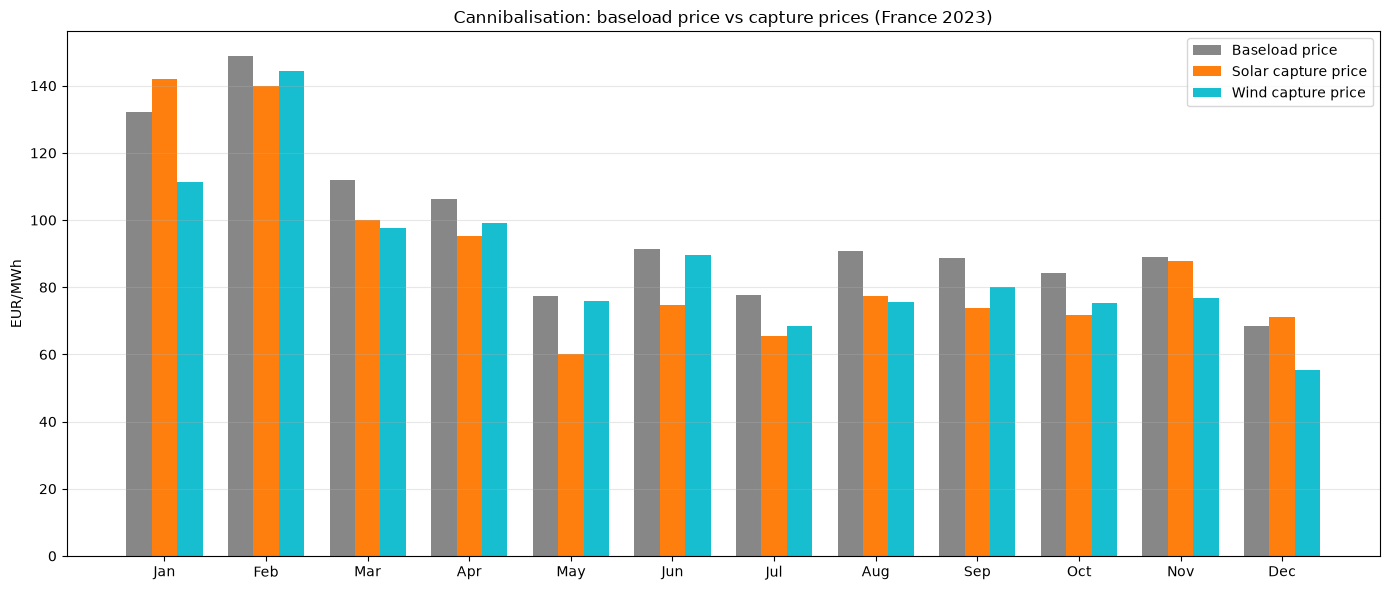

Baseload average     : 96.87 EUR/MWh
Solar capture price  : 81.98 EUR/MWh  (cannibalisation 15.4%)
Wind capture price   : 86.33 EUR/MWh  (cannibalisation 10.9%)


In [7]:
# =============================================================================
# 7. CAPTURE PRICES AND CANNIBALISATION
# =============================================================================
m['Month'] = m.index.month
m['Rev_Solar'] = m['Spot_Price'] * m['Solaire']
m['Rev_Wind'] = m['Spot_Price'] * m['Eolien']

monthly = m.groupby('Month')[['Rev_Solar', 'Solaire', 'Rev_Wind', 'Eolien']].sum()
solar_capture = monthly['Rev_Solar'] / monthly['Solaire']     # volume-weighted price
wind_capture = monthly['Rev_Wind'] / monthly['Eolien']
base_prices = m.groupby('Month')['Spot_Price'].mean()        # simple average

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
x = np.arange(12)
w = 0.25
plt.figure(figsize=(14, 6))
plt.bar(x - w, base_prices, w, label='Baseload price', color='#555555', alpha=0.7)
plt.bar(x, solar_capture, w, label='Solar capture price', color='#FF7F0E')
plt.bar(x + w, wind_capture, w, label='Wind capture price', color='#17BECF')
plt.ylabel('EUR/MWh')
plt.title('Cannibalisation: baseload price vs capture prices (France 2023)')
plt.xticks(x, months)
plt.legend()
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

avg_base = m['Spot_Price'].mean()
avg_solar = m['Rev_Solar'].sum() / m['Solaire'].sum()
avg_wind = m['Rev_Wind'].sum() / m['Eolien'].sum()
print(f"Baseload average     : {avg_base:.2f} EUR/MWh")
print(f"Solar capture price  : {avg_solar:.2f} EUR/MWh  (cannibalisation {1 - avg_solar / avg_base:.1%})")
print(f"Wind capture price   : {avg_wind:.2f} EUR/MWh  (cannibalisation {1 - avg_wind / avg_base:.1%})")

Load factor relative to peak output: solar 19.0%, wind 31.8%

Strategy   |    Solar EUR | Solar EUR/MWh |     Wind EUR | Wind EUR/MWh
------------------------------------------------------------------------
Merchant   |    1,364,240 |          82.0 |    2,406,575 |         86.3
PPA        |    1,381,206 |          83.0 |    2,425,195 |         87.0
Mixed      |    1,376,116 |          82.7 |    2,419,609 |         86.8
Wind earns more in absolute terms mainly because of its higher load factor; the EUR/MWh columns compare value per unit produced.


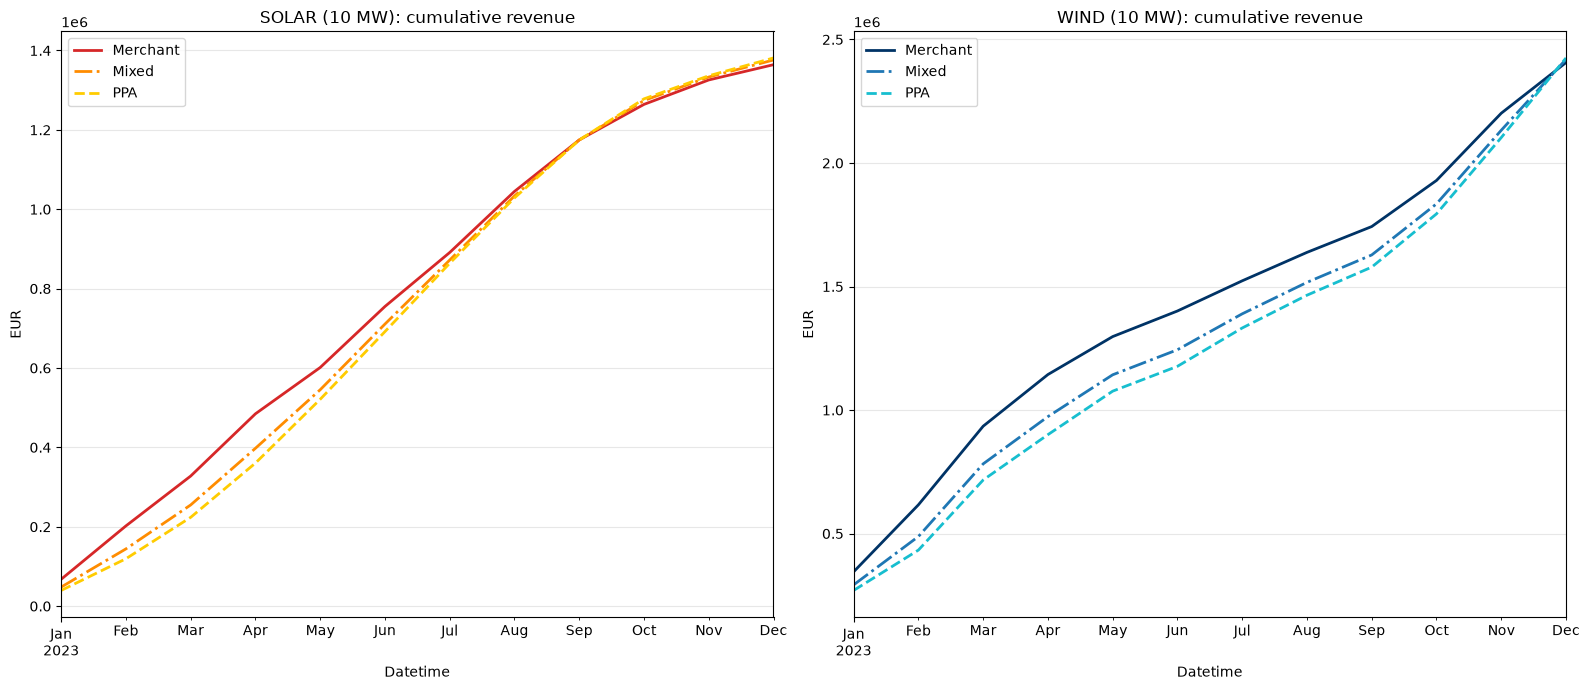


Strategy   | Solar vol (EUR) | Wind vol (EUR) | Wind vol vs merchant
----------------------------------------------------------------------
Merchant   |          39,869 |         85,005 |                  REF
Mixed      |          45,483 |         74,788 |                 -12%
PPA        |          50,130 |         76,838 |                 -10%


In [8]:
# =============================================================================
# 8. PORTFOLIO REVENUES: MERCHANT VS PPA VS MIXED
# =============================================================================
CAPACITY_MW = 10
# PPA strikes set at 2023 market levels: average awarded prices in the CRE
# tenders (ground-mounted solar 82-85 EUR/MWh, onshore wind 86.9 EUR/MWh).
PPA_SOLAR = 83   # EUR/MWh
PPA_WIND = 87    # EUR/MWh
HEDGE_MIX = 0.7

# Proxy: national generation scaled so that its annual peak equals 10 MW.
# Peak output is below installed capacity, so these load factors are higher
# than the true fleet capacity factors. Capture prices and hedge ratios are
# unaffected (scale-invariant); absolute revenues and MWh are overstated.
prod_solar = m['Solaire'] / m['Solaire'].max() * CAPACITY_MW
prod_wind = m['Eolien'] / m['Eolien'].max() * CAPACITY_MW
print(f"Load factor relative to peak output: solar {prod_solar.mean() / CAPACITY_MW:.1%}, "
      f"wind {prod_wind.mean() / CAPACITY_MW:.1%}")

rev = {}
for name, prod, strike in [('Solar', prod_solar, PPA_SOLAR), ('Wind', prod_wind, PPA_WIND)]:
    merchant = prod * m['Spot_Price']
    ppa = prod * strike                       # pay-as-produced PPA
    rev[name] = {'Merchant': merchant, 'PPA': ppa,
                 'Mixed': HEDGE_MIX * ppa + (1 - HEDGE_MIX) * merchant,
                 'MWh': prod.sum()}

print(f"\n{'Strategy':<10} | {'Solar EUR':>12} | {'Solar EUR/MWh':>13} | {'Wind EUR':>12} | {'Wind EUR/MWh':>12}")
print('-' * 72)
for s in ['Merchant', 'PPA', 'Mixed']:
    rs, rw = rev['Solar'][s].sum(), rev['Wind'][s].sum()
    print(f"{s:<10} | {rs:>12,.0f} | {rs / rev['Solar']['MWh']:>13.1f} | {rw:>12,.0f} | {rw / rev['Wind']['MWh']:>12.1f}")
print("Wind earns more in absolute terms mainly because of its higher load factor;"
      " the EUR/MWh columns compare value per unit produced.")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, name, cols in [(axes[0], 'Solar', ['#d62728', '#FF8C00', '#FFCC00']),
                       (axes[1], 'Wind', ['#003366', '#1F77B4', '#17BECF'])]:
    pd.DataFrame({s: rev[name][s].resample('ME').sum() for s in ['Merchant', 'Mixed', 'PPA']}).cumsum() \
        .plot(ax=ax, color=cols, linewidth=2, style=['-', '-.', '--'])
    ax.set_title(f"{name.upper()} ({CAPACITY_MW} MW): cumulative revenue")
    ax.set_ylabel("EUR")
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Risk: standard deviation of monthly revenue
print(f"\n{'Strategy':<10} | {'Solar vol (EUR)':>15} | {'Wind vol (EUR)':>14} | {'Wind vol vs merchant':>20}")
print('-' * 70)
vol = {n: {s: rev[n][s].resample('ME').sum().std() for s in ['Merchant', 'Mixed', 'PPA']} for n in rev}
for s in ['Merchant', 'Mixed', 'PPA']:
    red = 'REF' if s == 'Merchant' else f"{vol['Wind'][s] / vol['Wind']['Merchant'] - 1:+.0%}"
    print(f"{s:<10} | {vol['Solar'][s]:>15,.0f} | {vol['Wind'][s]:>14,.0f} | {red:>20}")

Wind : optimum at 70% PPA (ratio 2.70)
Solar: optimum at 0% PPA (ratio 2.85)
Wind: lowest volatility is -12% vs merchant; interior optimum
Solar: lowest volatility is +0% vs merchant; corner optimum


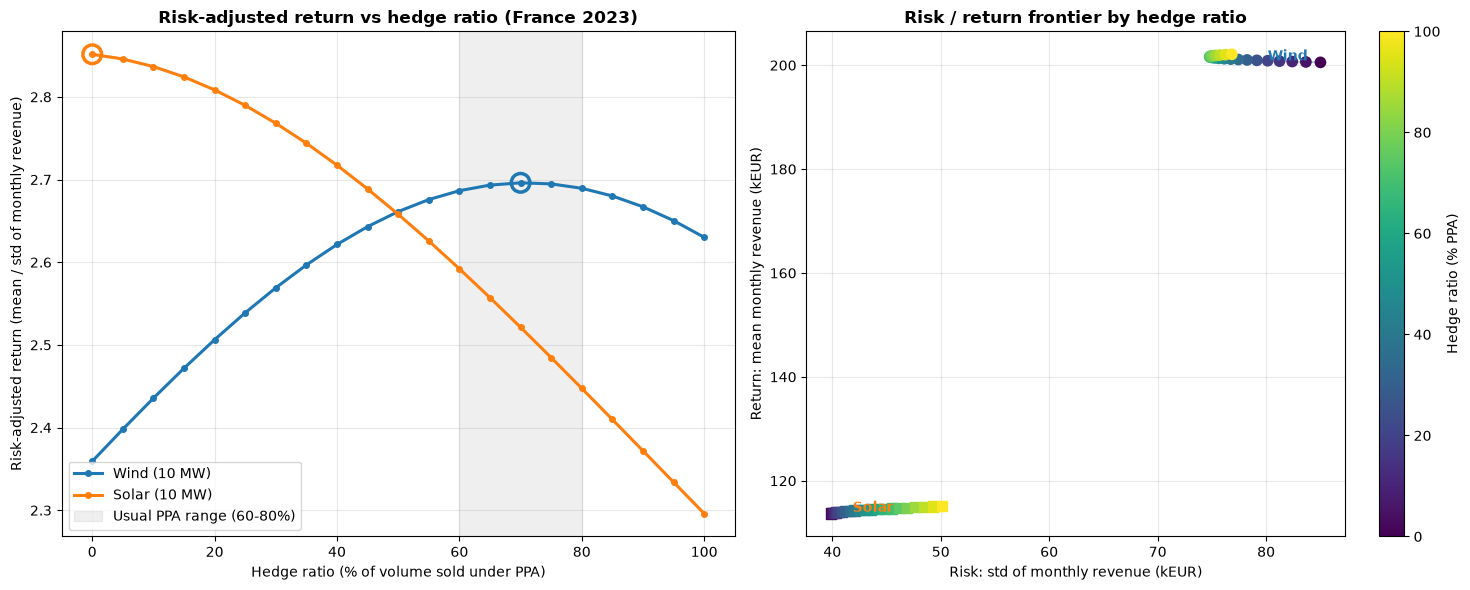

In [9]:
# =============================================================================
# 9. HEDGE-RATIO OPTIMISATION (RISK-ADJUSTED RETURN)
# =============================================================================
# Sweep the hedge ratio from 0% to 100% PPA in 5% steps.
# Metric: mean monthly revenue / standard deviation of monthly revenue
# (a Sharpe-like ratio, without a risk-free rate).
hedges = np.linspace(0, 1, 21)

def risk_return_curve(prod, strike):
    out = []
    for h in hedges:
        revenue = prod * strike * h + prod * m['Spot_Price'] * (1 - h)
        monthly_rev = revenue.resample('ME').sum()
        mu, sd = monthly_rev.mean(), monthly_rev.std()
        out.append((mu, sd, mu / sd if sd > 0 else np.nan))
    return np.array(out)

curve_wind = risk_return_curve(prod_wind, PPA_WIND)
curve_solar = risk_return_curve(prod_solar, PPA_SOLAR)
opt_w = int(np.nanargmax(curve_wind[:, 2]))
opt_s = int(np.nanargmax(curve_solar[:, 2]))

print(f"Wind : optimum at {hedges[opt_w]:.0%} PPA (ratio {curve_wind[opt_w, 2]:.2f})")
print(f"Solar: optimum at {hedges[opt_s]:.0%} PPA (ratio {curve_solar[opt_s, 2]:.2f})")
# Reading the curves
for name, curve, opt in [('Wind', curve_wind, opt_w), ('Solar', curve_solar, opt_s)]:
    vol_min = curve[:, 1].min() / curve[0, 1] - 1
    print(f"{name}: lowest volatility is {vol_min:+.0%} vs merchant; "
          f"{'interior optimum' if 0 < opt < len(hedges) - 1 else 'corner optimum'}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
ax1.plot(hedges * 100, curve_wind[:, 2], '-o', color='#1f77b4', linewidth=2.2, markersize=4, label='Wind (10 MW)')
ax1.plot(hedges * 100, curve_solar[:, 2], '-o', color='#ff7f0e', linewidth=2.2, markersize=4, label='Solar (10 MW)')
ax1.scatter([hedges[opt_w] * 100], [curve_wind[opt_w, 2]], s=180, facecolors='none', edgecolors='#1f77b4', linewidths=2.5, zorder=5)
ax1.scatter([hedges[opt_s] * 100], [curve_solar[opt_s, 2]], s=180, facecolors='none', edgecolors='#ff7f0e', linewidths=2.5, zorder=5)
ax1.axvspan(60, 80, color='grey', alpha=0.12, label='Usual PPA range (60-80%)')
ax1.set_xlabel('Hedge ratio (% of volume sold under PPA)')
ax1.set_ylabel('Risk-adjusted return (mean / std of monthly revenue)')
ax1.set_title('Risk-adjusted return vs hedge ratio (France 2023)', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

sc = ax2.scatter(curve_wind[:, 1] / 1e3, curve_wind[:, 0] / 1e3, c=hedges * 100, cmap='viridis', s=55, zorder=3)
ax2.plot(curve_wind[:, 1] / 1e3, curve_wind[:, 0] / 1e3, color='#1f77b4', alpha=0.4, linewidth=1.2)
ax2.scatter(curve_solar[:, 1] / 1e3, curve_solar[:, 0] / 1e3, c=hedges * 100, cmap='viridis', s=55, marker='s', zorder=3)
ax2.plot(curve_solar[:, 1] / 1e3, curve_solar[:, 0] / 1e3, color='#ff7f0e', alpha=0.5, linewidth=1.2, linestyle='--')
ax2.text(curve_wind[5, 1] / 1e3 + 1, curve_wind[5, 0] / 1e3, 'Wind', color='#1f77b4', fontweight='bold')
ax2.text(curve_solar[5, 1] / 1e3 + 1, curve_solar[5, 0] / 1e3, 'Solar', color='#ff7f0e', fontweight='bold')
plt.colorbar(sc, ax=ax2).set_label('Hedge ratio (% PPA)')
ax2.set_xlabel('Risk: std of monthly revenue (kEUR)')
ax2.set_ylabel('Return: mean monthly revenue (kEUR)')
ax2.set_title('Risk / return frontier by hedge ratio', fontweight='bold')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('hedging_frontier.png', dpi=140, bbox_inches='tight')
plt.show()

In [10]:
# =============================================================================
# 10. STRIKE SENSITIVITY AND NATURAL HEDGE
# =============================================================================
# The strike is an assumption, so check how much it drives the optimum.
print(f"{'Strike':>7} | {'Solar opt.':>10} | {'Wind opt.':>9} | {'Solar PPA EUR/MWh vs merchant':>29} | {'Wind PPA EUR/MWh vs merchant':>28}")
print('-' * 95)
for k in range(60, 101, 5):
    cs, cw = risk_return_curve(prod_solar, k), risk_return_curve(prod_wind, k)
    print(f"{k:>7} | {hedges[np.nanargmax(cs[:, 2])]:>10.0%} | {hedges[np.nanargmax(cw[:, 2])]:>9.0%} | "
          f"{k - avg_solar:>+29.1f} | {k - avg_wind:>+28.1f}")

# Why solar stays at 0%: monthly volume and monthly capture price move in opposite directions.
# A pay-as-produced PPA removes the price leg, and with it this natural offset.
print(f"\n{'':<6} | {'corr(volume, capture)':>21} | {'ratio volume only (100% PPA)':>28} | {'ratio merchant (0% PPA)':>23}")
print('-' * 88)
for name, prod in [('Solar', prod_solar), ('Wind', prod_wind)]:
    q = prod.resample('ME').sum()
    r = (prod * m['Spot_Price']).resample('ME').sum()
    print(f"{name:<6} | {q.corr(r / q):>21.2f} | {q.mean() / q.std():>28.2f} | {r.mean() / r.std():>23.2f}")


 Strike | Solar opt. | Wind opt. | Solar PPA EUR/MWh vs merchant | Wind PPA EUR/MWh vs merchant
-----------------------------------------------------------------------------------------------
     60 |         0% |       80% |                         -22.0 |                        -26.3
     65 |         0% |       75% |                         -17.0 |                        -21.3
     70 |         0% |       75% |                         -12.0 |                        -16.3
     75 |         0% |       75% |                          -7.0 |                        -11.3
     80 |         0% |       75% |                          -2.0 |                         -6.3
     85 |         0% |       70% |                          +3.0 |                         -1.3
     90 |         0% |       70% |                          +8.0 |                         +3.7
     95 |         0% |       70% |                         +13.0 |                         +8.7
    100 |         0% |       70% |      

## 11. Reading the results and limits of the risk metric

**The strike barely moves the optimum.** The mean/std ratio does not change when revenues are rescaled, so changing the strike only rescales the PPA leg: the best achievable ratio stays the same and the optimal hedge ratio shifts by a few points at most. The strike sets the *cost* of the hedge (EUR/MWh given up or gained against merchant), not where the risk-adjusted optimum lies.

**Wind:** the curve is concave and flat between roughly 60% and 90% PPA, with the best risk-adjusted return around 70-75%. At the 87 EUR/MWh strike, a 70% PPA cuts the standard deviation of monthly revenue by about 12% (more with a lower strike, since the fixed leg is then smaller). At the 2023 tender level (87 EUR/MWh), the PPA is also slightly above the wind capture price, so hedging costs nothing in 2023.

**Solar:** the optimum is 0% PPA at every strike tested (60 to 100 EUR/MWh). This is a natural hedge: months with high solar output (summer) have low capture prices, and vice versa (correlation about -0.6). Merchant revenue is therefore *more* stable than volume alone. A pay-as-produced PPA fixes the price and leaves the book exposed to the full seasonal volume swing, which raises relative volatility.

**Why this is not the whole story:** the standard deviation of 12 monthly revenues within one year treats the predictable seasonal shape as risk and ignores what a solar PPA is actually bought for: protection against a fall in the *level* of capture prices from one year to the next (2023 to 2024) and against growing cannibalisation as the solar fleet expands. A more rigorous version would measure risk as the deviation from an expected monthly profile over several years and price the strike from forwards.
